In [1]:
# расчет и визуализация
# магнитного поля, создаваемого
# постоянным кольцевым током

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt


In [2]:
# Ячейка № 2

# задание функции, возвращающей значения
# проекций напряженности магнитного поля,
# вычисляемых в соответствие с (5.21)-(5.23)
def Ring(a, X, Y, Z):
    # а - радиус кольцевого тока
    # X, Y, Z - координаты точки наблюдения

    # задание числа элементов, используемых для
    # аппроксимации кольцевого тока
    Nstep = 100

    # вычисление координат узлов сетки по переменной phi
    phi = np.linspace(0, 2 * np.pi, Nstep)

    # вычисление значения шага сетки по переменной phi
    delta_phi = phi[1] - phi[0]

    # вычисление значений
    # напряженности магнитного поля
    # в узлах выбранной координатной сетки
    # в соответствии с (5.21)-(5.23)
    bx = 0
    by = 0
    bz = 0
    for i in range(Nstep):
        R = np.sqrt(
            (X - a * np.cos(phi[i])) ** 2 + (Y - a * np.sin(phi[i])) ** 2 + Z**2
        )
        bx = bx - a * Z * np.cos(phi[i]) / R**3 * delta_phi
        by = by - a * Z * np.sin(phi[i]) / R**3 * delta_phi
        bz = (
            bz
            + (
                a * (Y - a * np.sin(phi[i])) * np.sin(phi[i])
                + a * (X - a * np.cos(phi[i])) * np.cos(phi[i])
            )
            / R**3
            * delta_phi
        )

    return bx, by, bz


In [3]:
# Ячейка № 3

# задание функции, возвращающей значения модуля
# векторного потенциала магнитного поля
# в точке с радиусом-вектором X, Y, Z
# в соответствие с (5.24)-(5.26)
def RingA(a, X, Y, Z):
    # а - радиус кольцевого тока
    # X, Y, Z - координаты точки наблюдения

    # задание числа элементов, используемых для
    # аппроксимации кольца
    Nstep = 100

    # вычисление координат узлов сетки по переменной phi
    phi = np.linspace(0, 2 * np.pi, Nstep)

    # вычисление значения шага сетки по переменной phi
    delta_phi = phi[1] - phi[0]

    # инициализация массива, используемого
    # для хранения значений модуля
    # векторного потенциала, вычисляемого
    # в соответствие с (5.22)
    A = np.zeros([Ny, Nz])

    # вычисление значений модуля
    # векторного потенциала магнитного поля
    # в точке наблюдения с координатми (X,Y,Z)
    # в соответствии с (5.22)
    Ax = 0
    Ay = 0
    for i in range(Nstep):
        R = np.sqrt(
            (X - a * np.cos(phi[i])) ** 2 + (Y - a * np.sin(phi[i])) ** 2 + Z**2
        )
        Ax = Ax + a * np.sin(phi[i]) / R * delta_phi
        Ay = Ay - a * np.cos(phi[i]) / R * delta_phi

        # вычисление модуля векторного потенциала
    A = np.sqrt(Ax**2 + Ay**2)

    return A

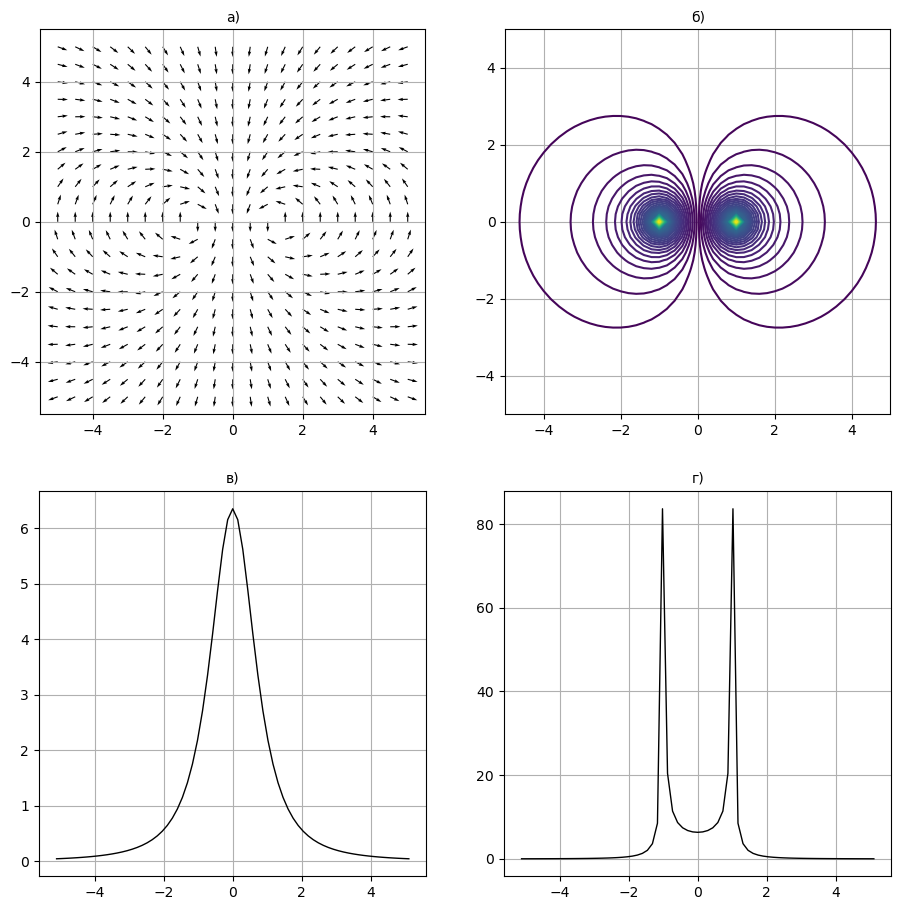

In [ ]:
# Ячейка № 4

# задание числа узлов координатной сетки
N1 = 21

# задание координат левого нижнего и
# правого верхнего узлов координатной сетки
Ymin = -5
Ymax = 5
Zmin = -5
Zmax = 5

# задание ординат узлов координатной сетки
Y = np.linspace(Ymin, Ymax, N1)

# задание аппликат узлов координатной сетки
Z = np.linspace(Zmin, Zmax, N1)

# определение числа узлов
# координатной сетки по оси ОY
Ny = len(Y)

# определение числа узлов
# координатной сетки по оси OZ
Nz = len(Z)

# создание матриц, используемых для визуализации
# векторного поля
[Y1, Z1] = np.meshgrid(Y, Z)
# задание радиуса кольца с током
a = 1

# инициализация массивов, используемых для
# для хранения значений напряженности магнитного поля,
# вычисляемого в соответствие с (5.21)-(5.23)
By = np.zeros([len(Y), len(Z)])
Bz = np.zeros([len(Y), len(Z)])

# вычисление составляющих напряженностей
# магнитного поля в узлах выбранной координатной сетки
# в соответствие c (5.21)
for i in range(Ny):
    for j in range(Nz):
        [bx, by, bz] = Ring(a, 0, Y1[i, j], Z1[i, j])
        By[i, j] = by
        Bz[i, j] = bz

# инициализация массива mp, используемого для
# для хранения значений модулей напряженностей
# магнитного поля в узлах выбранной координатной сетки
mp = np.zeros([Ny, Nz])

# вычисление  модулей напряженностей
# магнитного поля в узлах
# выбранной координатной сетки
for i in range(Ny):
    for j in range(Nz):
        mp[i, j] = np.sqrt(By[i, j] ** 2 + Bz[i, j] ** 2)

# инициализация массивов by1, bz1, используемых для
# для хранения значений координат единичных векторов,
# касательных к силовой линии магнитного поля,
# в узлах выбранной координатной сетки
by1 = np.zeros([Ny, Nz])
bz1 = np.zeros([Ny, Nz])

# вычисление абсцисс и аппликат единичных векторов,
# касательных к силовой линии магнитного поля,
# в узлах выбранной координатной сетки
for i in range(Ny):
    for j in range(Nz):
        by1[i, j] = By[i, j] / mp[i, j]
        bz1[i, j] = Bz[i, j] / mp[i, j]

N1 = 51
# задание ординат узлов координатной сетки
# по оси OY
y = np.linspace(Ymin, Ymax, N1)

# задание аппликат узлов координатной сетки
# по оси OZ
z = np.linspace(Zmin, Zmax, N1)

# определение числа узлов
# координатной сетки по оси OY
Ny2 = len(y)

# определение числа узлов
# координатной сетки по оси OZ
Nz2 = len(z)

# создание матриц, используемых для визуализации
# эквипотенциалей векторного потенциала
# магнитного поля
[Y2, Z2] = np.meshgrid(y, z)

# инициализация массива A, используемого для
# для хранения значений модуля
# векторного потенциала магнитного поля
# в узлах выбранной координатной сетки
A = np.zeros([Ny2, Nz2])

# вычисление модуля векторного потенциала
# в узлах выбранной координатной сетки
# в соответствие с (5.22)
for i in range(Ny2):
    for j in range(Nz2):
        A[i, j] = RingA(a, 0, Y2[i, j], Z2[i, j])

# вычисление модулей напряженностей магнитного поля
# в плоскости YOZ вдоль линий y = 0, z = 0
Ymin = -5.1
Ymax = 5.1
Zmin = -5.1
Zmax = 5.1

# задание числа узлов координатной сетки
N1 = 71

# задание ординат узлов координатной сетки
y = np.linspace(Ymin, Ymax, N1)

# задание аппликат узлов координатной сетки
z = np.linspace(Zmin, Zmax, N1)


Ny2 = len(y)
Nz2 = len(z)

# инициализация массива b1,
# используемого для хранения
# значений зависимости |B(0,0,z)|
b1 = np.zeros(Nz2)
# вычисление значений зависимости |B(0,0,z)|
for i in range(Nz2):
    [bx, by, bz] = Ring(a, 0, 0, z[i])
    b1[i] = np.sqrt(by**2 + bz**2)

# инициализация массива b2,
# используемого для хранения
# значений зависимости |B(0,0,z)|
b2 = np.zeros(Ny2)
# вычисление значений зависимости |B(0,y,0)|
for i in range(Ny2):
    [bx, by, bz] = Ring(a, 0, y[i], 0)
    b2[i] = np.sqrt(by**2 + bz**2)

# визуализация поля единичных векторов,
# касательных к силовой линии магнитного поля,
# и его силовых линий
# в узлах выбранной координатной сетки
fig = plt.figure(figsize=(11, 11))

# визуализация поля единичных векторов,
# касательных к силовой линии магнитного поля,
# в узлах выбранной координатной сетки
ax = fig.add_subplot(2, 2, 1)
q = ax.quiver(Y1, Z1, by1, bz1)
ax.set_title("а)", fontsize=10)
ax.grid(True)
ax.set_aspect("equal", "box")

# визуализация силовых линий магнитного поля,
# в узлах выбранной координатной сетки
ax = fig.add_subplot(2, 2, 2)
CS = ax.contour(Y2, Z2, A, levels=77)
ax.set_title("б)", fontsize=10)
ax.grid(True)
ax.set_aspect("equal", "box")


# визуализация зависимости |B(0,0,z)|
ax = fig.add_subplot(2, 2, 3)
ax.plot(z, b1, "-k", lw=1)
ax.set_title("в)", fontsize=10)
ax.grid(True)

# визуализация зависимости |B(0,y,0)|
ax = fig.add_subplot(2, 2, 4)
ax.plot(y, b2, "-k", lw=1)
ax.set_title("г)", fontsize=10)
ax.grid(True)

plt.show()